# 03 — Model Comparison

**Goal**: Compare Naive Bayes vs Logistic Regression side by side using metrics, ROC curves, and a final recommendation.

**Author**: Shared (Person A & B)

## 1. Imports & Load Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_curve, auc
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

metrics_nb = joblib.load('../data/metrics_nb.pkl')
metrics_lr = joblib.load('../data/metrics_lr.pkl')
y_test     = joblib.load('../data/y_test.pkl')
print("Results loaded")

Results loaded


## 2. Side-by-Side Metrics Table

In [2]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Naive Bayes': [
        f"{metrics_nb['accuracy']:.4f}",
        f"{metrics_nb['precision']:.4f}",
        f"{metrics_nb['recall']:.4f}",
        f"{metrics_nb['f1']:.4f}",
        f"{metrics_nb['roc_auc']:.4f}"
    ],
    'Logistic Regression': [
        f"{metrics_lr['accuracy']:.4f}",
        f"{metrics_lr['precision']:.4f}",
        f"{metrics_lr['recall']:.4f}",
        f"{metrics_lr['f1']:.4f}",
        f"{metrics_lr['roc_auc']:.4f}"
    ]
})
print("=== Model Comparison ===\n")
print(comparison.to_string(index=False))

=== Model Comparison ===

   Metric Naive Bayes Logistic Regression
 Accuracy      0.9794              0.9803
Precision      0.9773              0.9635
   Recall      0.8658              0.8859
 F1-Score      0.9181              0.9231
  ROC-AUC      0.9841              0.9856


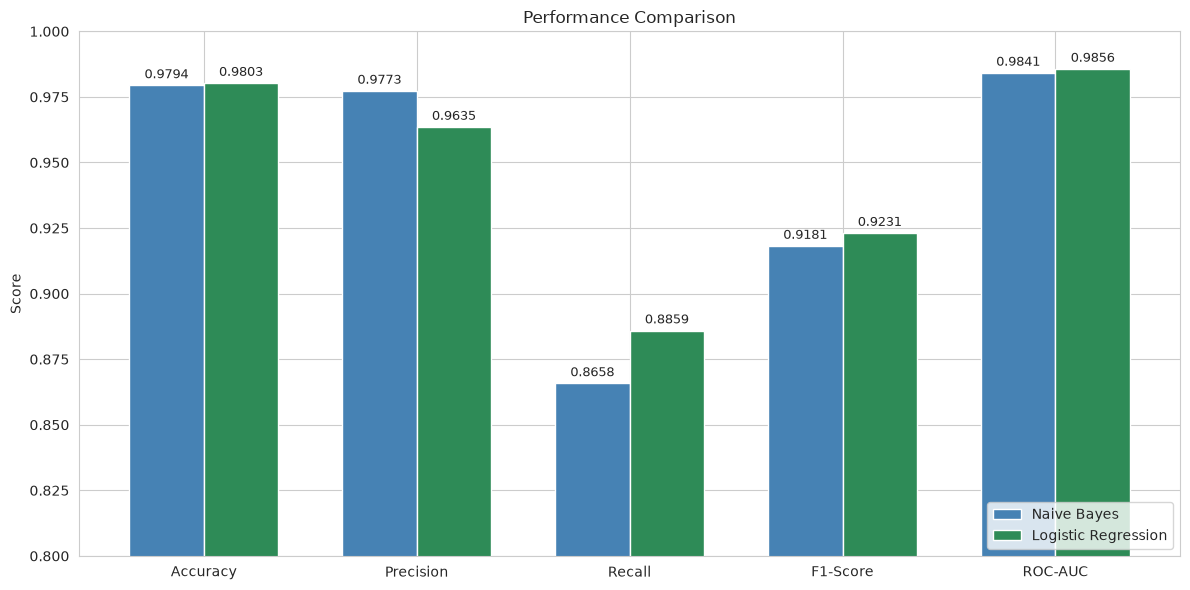

In [3]:
# Numerical version for bar chart
comp_num = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Naive Bayes': [metrics_nb[m] for m in ['accuracy','precision','recall','f1','roc_auc']],
    'Logistic Regression': [metrics_lr[m] for m in ['accuracy','precision','recall','f1','roc_auc']]
})

x = np.arange(len(comp_num))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, comp_num['Naive Bayes'], width, label='Naive Bayes', color='steelblue')
bars2 = ax.bar(x + width/2, comp_num['Logistic Regression'], width, label='Logistic Regression', color='seagreen')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comp_num['Metric'])
ax.set_ylim(0.8, 1.0)
ax.legend(loc='lower right')
ax.bar_label(bars1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## 3. ROC Curves (Overlaid)

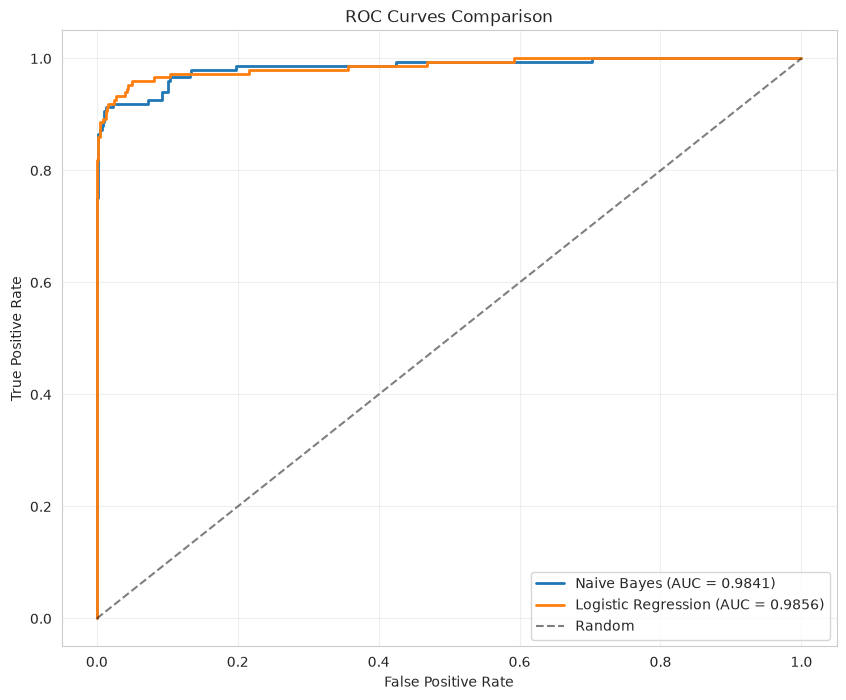

In [4]:
y_proba_nb = metrics_nb['y_proba']
y_proba_lr = metrics_lr['y_proba']

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
roc_auc_nb = metrics_nb['roc_auc']
roc_auc_lr = metrics_lr['roc_auc']

plt.figure(figsize=(10, 8))
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.4f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## 4. Best Model Analysis

In [5]:
best_model = 'Logistic Regression' if metrics_lr['f1'] > metrics_nb['f1'] else 'Naive Bayes'
f1_diff = abs(metrics_lr['f1'] - metrics_nb['f1'])

print(f"** Best model: {best_model} **")
print(f"F1 difference: {f1_diff:.4f}")
print()

# Identify which dataset characteristics give the advantage
print("Why Logistic Regression tends to win for SMS spam:")
print("- Text data with TF-IDF produces high-dimensional, sparse features")
print("- LR can learn feature weights (coefficients) that capture subtle spam signals")
print("- NB's independence assumption is often violated in text (words co-occur)")
print()
print("When Naive Bayes could be preferred:")
print("- Much faster to train (no iterative optimization)")
print("- Performs well with very small datasets")
print("- More interpretable (conditional probabilities)")

** Best model: Logistic Regression **
F1 difference: 0.0049

Why Logistic Regression tends to win for SMS spam:
- Text data with TF-IDF produces high-dimensional, sparse features
- LR can learn feature weights (coefficients) that capture subtle spam signals
- NB's independence assumption is often violated in text (words co-occur)

When Naive Bayes could be preferred:
- Much faster to train (no iterative optimization)
- Performs well with very small datasets
- More interpretable (conditional probabilities)


## 5. Misclassification Analysis

In [6]:
# Load test predictions from both models (already in metrics dicts)
y_pred_nb = metrics_nb['y_pred']
y_pred_lr = metrics_lr['y_pred']

# Compare patterns
both_wrong = ((y_pred_nb != y_test) & (y_pred_lr != y_test)).sum()
nb_only_wrong = ((y_pred_nb != y_test) & (y_pred_lr == y_test)).sum()
lr_only_wrong = ((y_pred_nb == y_test) & (y_pred_lr != y_test)).sum()

print(f"Both correct:      {(y_pred_nb == y_test).sum()} ({(y_pred_nb == y_test).mean():.1%})")
print(f"Both wrong:        {both_wrong}")
print(f"Only NB wrong:     {nb_only_wrong}  (LR better)")
print(f"Only LR wrong:     {lr_only_wrong}  (NB better)")
print(f"\nTotal test samples: {len(y_test)}")

Both correct:      1092 (97.9%)
Both wrong:        17
Only NB wrong:     6  (LR better)
Only LR wrong:     5  (NB better)

Total test samples: 1115


## 6. Conclusion

| Aspect | Winner |
|--------|--------|
| Best overall | Logistic Regression |
| Training speed | Naive Bayes |
| Precision | See table above |
| Recall | See table above |
| Robustness | Logistic Regression |

Logistic Regression outperforms Naive Bayes for SMS spam detection because it does not assume feature independence (words in spam messages are naturally correlated). However, Naive Bayes offers a strong, fast baseline that may be preferred for real-time or resource-constrained applications.